In [1]:
import numpy as np
from qutip import *
import plotly.graph_objects as go

# ============================================================
# --- Custom Plotly Template ---
# ============================================================
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.5,
        'tickwidth': 2.5,
        'ticklen': 4,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.5,
        'tickwidth': 2.5,
        'ticklen': 4,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'font': {
        'family': 'mathjax',
        'size': 30,
    }
}

In [2]:
def NV_spinNcharge(parameters, tlist, psi0, drive=-1):

    Bx, By, Bz, gamma_rel, gamma_deph, gamma_p, gamma_0, gamma_f0, gamma_f1, gamma_s0, gamma_s1, gamma_ion, gamma_es_nv, gamma_532_nv, gamma_rec, B1 = parameters

    # Hamiltonian Parameters
    D = 2870          # MHz
    g = 28025         # MHz/T

    # Operators
    n_states = 9
    spin_states = 3
    rho = np.zeros((n_states,n_states),dtype=complex)

    # Pauli Operators
    sx = rho.copy()
    sx[:spin_states,:spin_states] = jmat(1,'x').full()
    sx = Qobj(sx)
    sy = rho.copy()
    sy[:spin_states,:spin_states] = jmat(1,'y').full()
    sy = Qobj(sy)
    sz = rho.copy()
    sz[:spin_states,:spin_states] = jmat(1,'z').full()
    sz = Qobj(sz)
    s_plus = rho.copy()
    s_plus[:spin_states,:spin_states] = jmat(1,'+').full()
    s_plus = Qobj(s_plus)
    s_minus = rho.copy()
    s_minus[:spin_states,:spin_states] = jmat(1,'-').full()
    s_minus = Qobj(s_minus)

    # Other Operators
    # |g> --> |e>
    excitation = rho.copy()
    excitation[3,0] = np.sqrt(gamma_p)
    excitation[4,1] = np.sqrt(gamma_p)
    excitation[5,2] = np.sqrt(gamma_p)
    excitation = Qobj(excitation)

    # |e> --> |g>
    emission = rho.copy()
    emission[0,3] = np.sqrt(gamma_0)
    emission[1,4] = np.sqrt(gamma_0)
    emission[2,5] = np.sqrt(gamma_0)
    emission = Qobj(emission)

    # |e+1> --> |s>
    singlet_in1p = rho.copy()
    singlet_in1p[6,3] = np.sqrt(gamma_f1) 
    singlet_in1p = Qobj(singlet_in1p)

    # |e0> --> |s>
    singlet_in0 = rho.copy()
    singlet_in0[6,4] = np.sqrt(gamma_f0) 
    singlet_in0 = Qobj(singlet_in0)

    # |e-1> --> |s>
    singlet_in1m = rho.copy()
    singlet_in1m[6,5] = np.sqrt(gamma_f1) 
    singlet_in1m = Qobj(singlet_in1m)

    # |s> --> |g+1>
    singlet_out1p = rho.copy()
    singlet_out1p[0,6] = np.sqrt(gamma_s1)  
    singlet_out1p = Qobj(singlet_out1p)

    # |s> --> |g0>
    singlet_out0 = rho.copy()
    singlet_out0[1,6] = np.sqrt(gamma_s0) 
    singlet_out0 = Qobj(singlet_out0)

    # |s> --> |g-1>
    singlet_out1m = rho.copy()
    singlet_out1m[2,6] = np.sqrt(gamma_s1) 
    singlet_out1m = Qobj(singlet_out1m)
    
    # |e> --> |0g>
    nv0_in = rho.copy()
    nv0_in[7,3] = np.sqrt(gamma_ion/2)
    nv0_in[7,4] = np.sqrt(gamma_ion)
    nv0_in[7,5] = np.sqrt(gamma_ion/2)
    nv0_in = Qobj(nv0_in)

    # |0e> --> |0g>
    nv0_emission = rho.copy()
    nv0_emission[7,8] = np.sqrt(gamma_es_nv)
    nv0_emission = Qobj(nv0_emission)

    # |0g> --> |0e>
    nv0_excitation = rho.copy()
    nv0_excitation[8,7] = np.sqrt(gamma_532_nv)
    nv0_excitation = Qobj(nv0_excitation)

    # |0e> --> |g>
    nv0_out = rho.copy()
    nv0_out[0,8] = np.sqrt(gamma_rec/3)
    nv0_out[1,8] = np.sqrt(gamma_rec/3)
    nv0_out[2,8] = np.sqrt(gamma_rec/3)
    nv0_out = Qobj(nv0_out)

    # Time-independent Hamiltonian
            

    H0 = D*(sz**2 - 2/3) + g*sz*Bz + g*(sx*Bx + sy*By)
    
    # Solve for eigenenergies and eigenstates
    eigenenergies, eigenstates = H0.eigenstates()

    eigenenergies = np.unique(eigenenergies)

    if drive == -1:
        omega = eigenenergies[1]-eigenenergies[0]
        # print(f"Resonant frequency is {omega} MHz")
    else:
        omega = eigenenergies[2]-eigenenergies[0]
        # print(f"Resonant frequency is {omega} MHz")

    
    H1 = g * sx * B1
    H_drive = [[H1, lambda t, args: np.cos(omega * t)]]

    # Total Hamiltonian
    H = [H0] + H_drive

    # Collapse operators
    c_ops = [
            np.sqrt(gamma_rel/2) * s_minus,     # T1 Relaxation (Sigma_minus)
            np.sqrt(gamma_rel/2) * s_plus,      # T1 Relaxation (sigma_plus)
            np.sqrt(gamma_deph/2) * sz,         # Dephasing
            excitation,                       # Excitation
            emission,                         # Emission
            singlet_in1p,                     # |e+1> --> |s>
            singlet_in0,                      # |e0> --> |s>
            singlet_in1m,                     # |e-1> --> |s>
            singlet_out1p,                    # |s> --> |g+1>
            singlet_out0,                     # |s> --> |g0>
            singlet_out1m,                    # |s> --> |g-1>
            nv0_emission,                     # |0e> --> |0g>
            nv0_excitation,                   # |0g> --> |0e>
            nv0_in,                           # |e> --> |0g>
            nv0_out                           # |0e> --> |g>
            ]


    # Observables to record
    expect_ops = [basis(n_states, 0)*basis(n_states, 0).dag(),  # |+1_g> Population
                basis(n_states, 1)*basis(n_states, 1).dag(),  # |0_g> Population
                basis(n_states, 2)*basis(n_states, 2).dag(),  # |-1_g> Population
                basis(n_states, 3)*basis(n_states, 3).dag(),  # |+1_e> Population
                basis(n_states, 4)*basis(n_states, 4).dag(),  # |0_e> Population
                basis(n_states, 5)*basis(n_states, 5).dag(),  # |-1_e> Population
                basis(n_states, 6)*basis(n_states, 6).dag(),  # |s> Population
                basis(n_states, 7)*basis(n_states, 7).dag(),  # |nv_0_g> Population
                basis(n_states, 8)*basis(n_states, 8).dag(),  # |nv_0_e> Population
                ]

    # Solve the master equation
    result = mesolve(H, psi0, tlist, c_ops, expect_ops,
                   options={"store_final_state": True, "nsteps": 1e4},
                  #  options={"store_states": True},
                   )

    return result.expect, result.final_state

In [3]:
def nv_hamiltonian(Bx, By, Bz):
    # Parameters
    D = 2870          # MHz
    g = 28025         # MHz/T

    # Pauli matrices and operators
    sx = jmat(1,'x')
    sy = jmat(1,'y')
    sz = jmat(1,'z')
    s_minus = jmat(1,'-')
    s_plus = jmat(1,'+')


    H0 = D*(sz**2 - 2/3) + g*sz*Bz + g*(sx*Bx + sy*By)
    
    # Solve for eigenenergies and eigenstates
    eigenenergies, eigenstates = H0.eigenstates()

In [4]:
def nv_parameters(gamma_rel=0.0001, gamma_deph=0.001, power_laser=100, B1=0):
    Bx = 0                  # Static magnetic along x in tesla
    By = 0                  # Static magnetic along y in tesla
    Bz = 0.01               # Static magnetic along z in tesla
    c = 0.1                 # MHz/uW
    d = 0.025               # MHz/uW

    gamma_p = c*power_laser   # Laser excitation rate
    gamma_0 = 63              # NV- Radiative emission rate 
    gamma_s0_in = 12          # NV- Excited 0 to singlet
    gamma_s1_in = 80          # NV- Excited 1 to singlet
    gamma_s0_out = 3.3        # NV- Singlet to ground 0
    gamma_s1_out = 2.4        # NV- Singlet to ground 1
    gamma_ion = 3.8           # NV- excited state to NV0 ground state          
    gamma_es_nv = 16          # NV0 excited state to NV0 ground state
    gamma_532_nv = d*power_laser
    gamma_rec = 6.3           # NV0 excited to NV- ground 
    
    parameters = [Bx, By, Bz, gamma_rel, gamma_deph, gamma_p, gamma_0, gamma_s0_in, gamma_s1_in, gamma_s0_out, gamma_s1_out, gamma_ion, gamma_es_nv, gamma_532_nv, gamma_rec, B1]

    return parameters

In [5]:
def initialize(psi0=(1/3)*ket2dm(basis(9, 0)) + (1/3)*ket2dm(basis(9, 1)) + (1/3)*ket2dm(basis(9, 2)),
               gamma_rel=0.0001, gamma_deph=0.001, power_laser=100, B1=0, duration=5, drive=-1):
    
    parameters = nv_parameters(gamma_rel, gamma_deph, power_laser, B1)
    
    # Time array
    tlist = np.linspace(0, duration, 1001)  # Time in us
    
    populations, psi = NV_spinNcharge(parameters, tlist, psi0)
    
    return populations, psi, tlist    

########################################################################################################

def rabi(psi0=(1/3)*ket2dm(basis(9, 0)) + (1/3)*ket2dm(basis(9, 1)) + (1/3)*ket2dm(basis(9, 2)),
               gamma_rel=0.0001, gamma_deph=0.001, power_laser=0, B1=0.00164, duration=5, drive=-1):
    
    parameters = nv_parameters(gamma_rel, gamma_deph, power_laser, B1)
    
    # Time array
    tlist = np.linspace(0, duration, 101)  # Time in us
    
    populations, psi = NV_spinNcharge(parameters, tlist, psi0, drive)
    
    return populations, psi, tlist  

########################################################################################################

def evolve(psi0=(1/3)*ket2dm(basis(9, 0)) + (1/3)*ket2dm(basis(9, 1)) + (1/3)*ket2dm(basis(9, 2)),
               gamma_rel=0.0001, gamma_deph=0.001, power_laser=0, B1=0, duration=0.1, drive=-1):
    
    parameters = nv_parameters(gamma_rel, gamma_deph, power_laser, B1)
    
    # Time array
    tlist = np.linspace(0, duration, 101)  # Time in us
    
    populations, psi = NV_spinNcharge(parameters, tlist, psi0, drive)
    
    return populations, psi, tlist  

########################################################################################################

def read(psi0=(1/3)*ket2dm(basis(9, 0)) + (1/3)*ket2dm(basis(9, 1)) + (1/3)*ket2dm(basis(9, 2)),
               gamma_rel=0.0001, gamma_deph=0.001, power_laser=100, B1=0, duration=5, drive=-1):
    
    parameters = nv_parameters(gamma_rel, gamma_deph, power_laser, B1)
    
    # Time array
    tlist = np.linspace(0, duration, 1001)  # Time in us
    
    populations, psi = NV_spinNcharge(parameters, tlist, psi0)
    
    return populations, psi, tlist  

########################################################################################################

def count(populations,tlist,duration=0.5):
    index = np.argwhere(tlist<=0.5)[-1][0]
    # print(index)
    n = np.mean(np.array(populations[3:6])[:,:index+1])
    # print(np.array(populations3[3:6])[:,:index+1])
    return n

In [6]:
populations1,psi1,tlist=initialize()
g1p_pop,g0_pop, g1m_pop,e1p_pop,e0_pop,e1m_pop,s_pop, nv0g_pop, nv0e_pop = populations1

populations2,psi2,tlist = evolve(psi1,duration=0.02)
g1p_pop,g0_pop, g1m_pop,e1p_pop,e0_pop,e1m_pop,s_pop, nv0g_pop, nv0e_pop = populations2

populations3,psi3,tlist = rabi(psi2,duration=0.1)
g1p_pop,g0_pop, g1m_pop,e1p_pop,e0_pop,e1m_pop,s_pop, nv0g_pop, nv0e_pop = populations2

populations4,psi4,tlist=read(psi3)
g1p_pop,g0_pop, g1m_pop,e1p_pop,e0_pop,e1m_pop,s_pop, nv0g_pop, nv0e_pop = populations4
counts_1 = count(populations4, tlist)

D:\other_softwares\Anaconda\Anaconda_installations\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


In [7]:
g1p_pop,g0_pop, g1m_pop,e1p_pop,e0_pop,e1m_pop,s_pop, nv0g_pop, nv0e_pop,tlist

(array([0.12698874, 0.12245891, 0.11916753, ..., 0.08621656, 0.08621638,
        0.08621621], shape=(1001,)),
 array([0.13198505, 0.12765039, 0.12495656, ..., 0.32423114, 0.32422978,
        0.32422843], shape=(1001,)),
 array([0.40398492, 0.38762534, 0.37510872, ..., 0.08621656, 0.08621638,
        0.08621621], shape=(1001,)),
 array([5.21517438e-09, 4.42184003e-03, 6.43096031e-03, ...,
        5.96137565e-03, 5.96136352e-03, 5.96135144e-03], shape=(1001,)),
 array([3.30659505e-06, 5.35465951e-03, 8.82401060e-03, ...,
        4.11847697e-02, 4.11845948e-02, 4.11844207e-02], shape=(1001,)),
 array([5.21517436e-09, 1.40289739e-02, 2.03301757e-02, ...,
        5.96137565e-03, 5.96136351e-03, 5.96135144e-03], shape=(1001,)),
 array([0.07317159, 0.07454442, 0.08110331, ..., 0.17878401, 0.17878345,
        0.17878288], shape=(1001,)),
 array([0.26200073, 0.25916524, 0.25677895, ..., 0.24408298, 0.24408519,
        0.24408739], shape=(1001,)),
 array([0.00186565, 0.00475022, 0.00729979, ...,

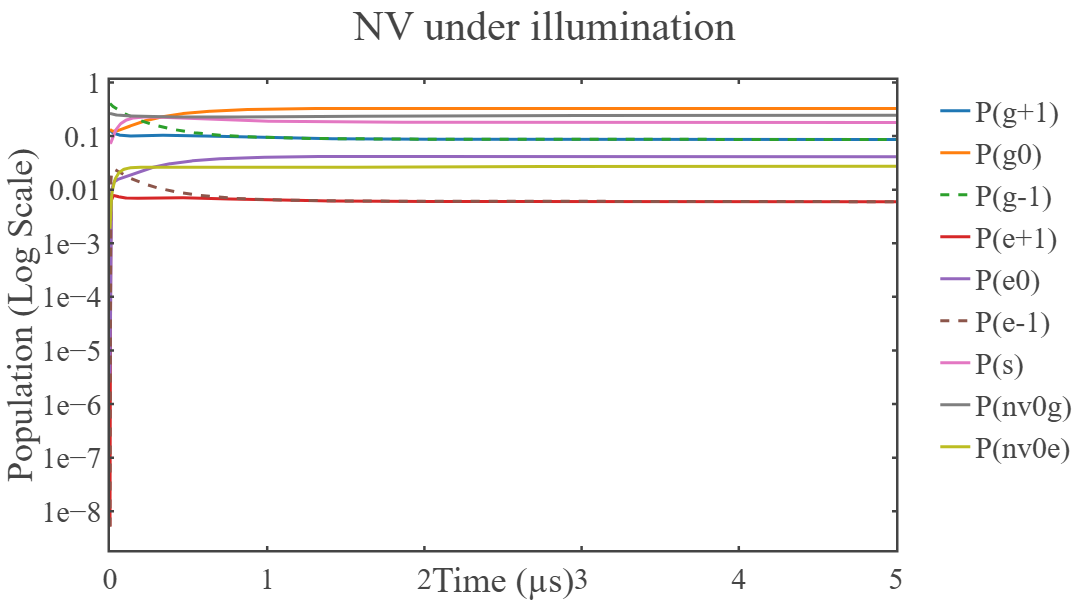

In [8]:
import plotly.graph_objects as go

fig = go.Figure()

# Standard Plotly trace addition
fig.add_trace(go.Scatter(x=tlist, y=g1p_pop, name='P(g+1)', mode='lines', line=dict(width=3)))
fig.add_trace(go.Scatter(x=tlist, y=g0_pop,  name='P(g0)',  mode='lines', line=dict(width=3)))
fig.add_trace(go.Scatter(x=tlist, y=g1m_pop, name='P(g-1)', mode='lines', line=dict(width=3, dash='dash'))) # Dashed to see overlap
fig.add_trace(go.Scatter(x=tlist, y=e1p_pop, name='P(e+1)', mode='lines', line=dict(width=3)))
fig.add_trace(go.Scatter(x=tlist, y=e0_pop,  name='P(e0)',  mode='lines', line=dict(width=3)))
fig.add_trace(go.Scatter(x=tlist, y=e1m_pop, name='P(e-1)', mode='lines', line=dict(width=3, dash='dash'))) # Dashed to see overlap
fig.add_trace(go.Scatter(x=tlist, y=s_pop,   name='P(s)',   mode='lines', line=dict(width=3)))
fig.add_trace(go.Scatter(x=tlist, y=nv0g_pop,name='P(nv0g)',mode='lines', line=dict(width=3)))
fig.add_trace(go.Scatter(x=tlist, y=nv0e_pop,name='P(nv0e)',mode='lines', line=dict(width=3)))

fig.update_layout(
    template=fig_template, # Commented out temporarily to ensure it isn't hiding traces
    height=600, 
    width=800,
    margin=dict(l=110, r=50, t=80, b=50),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.05),
    xaxis=dict(title="Time (µs)"),
    yaxis=dict(
        title="Population (Log Scale)", 
        type="log",              # Switches to logarithmic scale
        exponentformat="e"       # Shows 1e-4 instead of 0.0001
    ),
    title="NV under illumination",
)

fig.show()